In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

Ejemplo de diseño y aplicación de filtro Savitzky-Golay (FIR)

Inicialmente se crea una señal de prueba con varios armónicos para observar el desempeño de los filtros
También se calcula su espectro de frecuencia usando la FFT

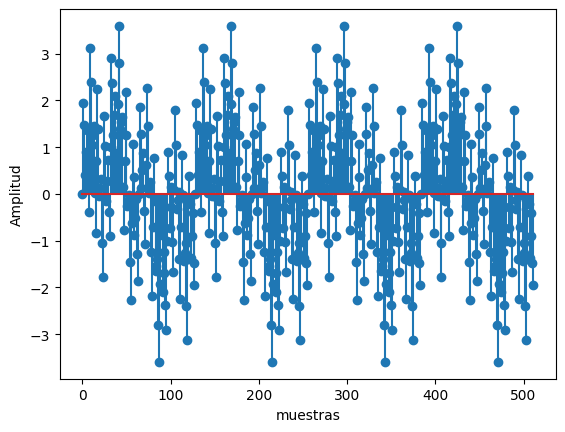

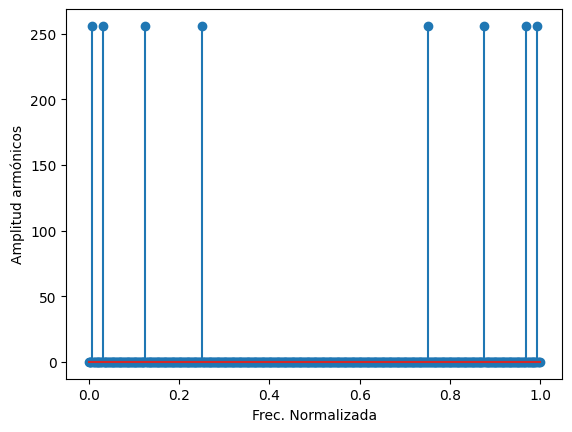

In [20]:
n = np.arange(0,512)
k = n/512
xn=np.sin(2*np.pi*n*1/4)+np.sin(2*np.pi*n*1/8)+np.sin(2*np.pi*n*1/32)+np.sin(2*np.pi*n*1/128)
Xk = abs(np.fft.fft(xn))

# Graficos

#señal
plt.figure(1)
plt.stem(n,xn)
plt.xlabel('muestras')
plt.ylabel('Amplitud')

#magnitud del espectro
plt.figure(2)
plt.stem(k,Xk)
plt.xlabel('Frec. Normalizada')
plt.ylabel('Amplitud armónicos')
plt.show()

Obtención de coeficientes del filtro

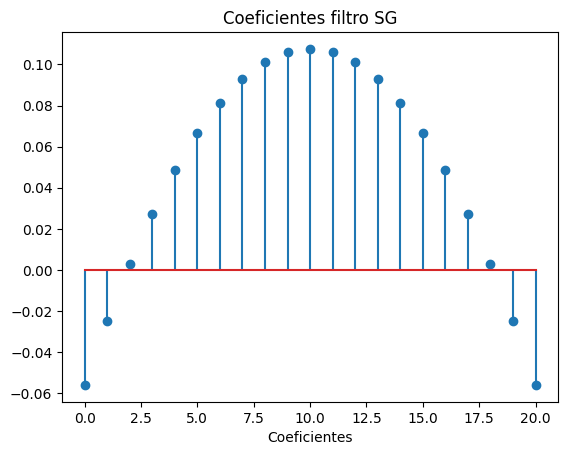

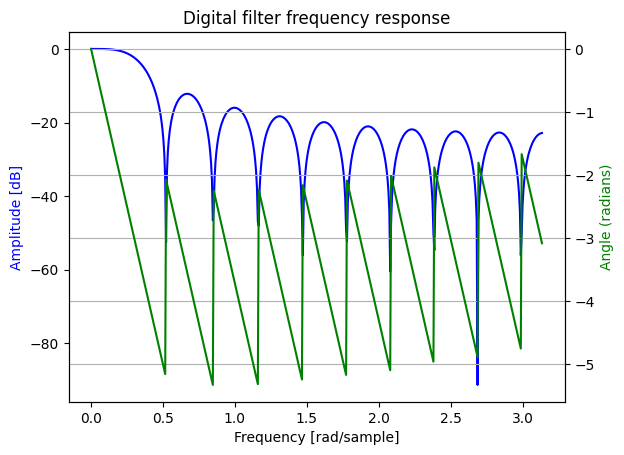

In [21]:
m = 3 # orden del polinomio
fl = 21 # longitud del filtro
hn = signal.savgol_coeffs(fl,m)

# Aplicando ventana
#window = signal.get_window('hamm', len(hn)) # 'hann' 'black'
#hn = hn * window

plt.figure(1)
plt.stem(np.arange(0,len(hn)),hn)
plt.title('Coeficientes filtro SG')
plt.xlabel('Coeficientes')
plt.show()

#Respuesta en frecuencia del filtro
w, h = signal.freqz(hn)
fig, ax1 = plt.subplots()
ax1.set_title('Digital filter frequency response')
ax1.plot(w, 20 * np.log10(abs(h)), 'b')
ax1.set_ylabel('Amplitude [dB]', color='b')
ax1.set_xlabel('Frequency [rad/sample]')
ax2 = ax1.twinx()
angles = np.unwrap(np.angle(h))
ax2.plot(w, angles, 'g')
ax2.set_ylabel('Angle (radians)', color='g')
ax2.grid(True)
ax2.axis('tight')
plt.show()

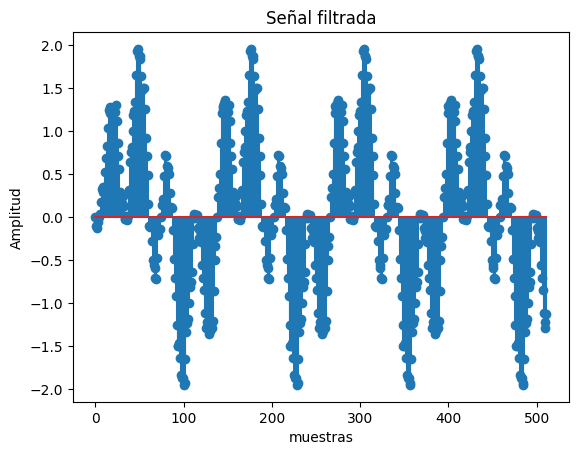

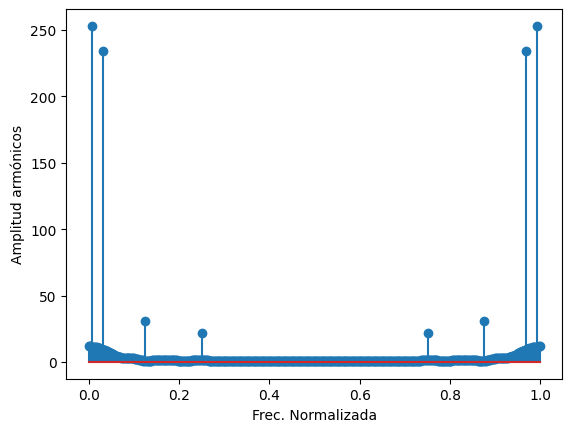

In [22]:
# Filtrar la señal con el filtro obtenido
yn = signal.lfilter(hn,1,xn)
plt.figure()
plt.stem(n,yn)
plt.xlabel('muestras')
plt.ylabel('Amplitud')
plt.title('Señal filtrada')

plt.figure()
plt.stem(k,abs(np.fft.fft(yn)))
plt.xlabel('Frec. Normalizada')
plt.ylabel('Amplitud armónicos')
plt.show()